# ODIR-5K Retinal Disease Classification
**Model:** EfficientNet-B3 | **Task:** Multi-label Classification (7 classes) | **Metric:** Macro AUC-ROC

## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import timm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

print('All imports successful')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

All imports successful
PyTorch version: 2.10.0+cu128
Device: cuda


## 2. Paths & Config

In [ ]:
# please change paths accordingly, I wrote this notebook in kaggle.
IMG_DIR = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/'
ANNO_PATH = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/data.xlsx'


PREPROCESSED_DIR = '/kaggle/working/preprocessed/'
BEST_MODEL_PATH = '/kaggle/working/best_model.pth'
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
LABEL_COLS = ['N', 'D', 'G', 'C', 'A', 'H', 'M']

print('Paths and config set')
print(f'Training images: {IMG_DIR}')
print(f'Annotation file: {ANNO_PATH}')

Paths and config set
Training images: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/
Annotation file: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/data.xlsx


## 3. Load & Clean Annotations

In [26]:
df = pd.read_excel(ANNO_PATH)
print(f'Raw shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Raw shape: (3500, 15)
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [ ]:
# Drop O (Other) class  as it is noisy and not clinically meaningful
df = df.drop(columns=['O'])

# Removing patients whose only label was O as they are all 0 now
df_clean = df[df[LABEL_COLS].sum(axis=1) > 0].copy()
print(f'Removed {len(df) - len(df_clean)} O-only patients')
print(f'Remaining patients: {len(df_clean)}')

# Class distribution
print('\nClass distribution:')
print(df_clean[LABEL_COLS].sum().sort_values(ascending=False))

Removed 551 O-only patients
Remaining patients: 2949

Class distribution:
N    1140
D    1128
G     215
C     212
M     174
A     164
H     103
dtype: int64


## 4. Identify & Remove Bad Images

In [28]:
bad_images = []

for _, row in df_clean.iterrows():
    for eye in ['Left-Fundus', 'Right-Fundus']:
        path = IMG_DIR + row[eye]
        img = np.array(Image.open(path).convert('RGB'))
        if img.mean() < 10:
            bad_images.append(row[eye])

print(f'Bad images found: {len(bad_images)}')
print(bad_images)

Bad images found: 14
['1209_left.jpg', '1212_right.jpg', '1225_right.jpg', '1260_right.jpg', '1422_left.jpg', '2133_right.jpg', '2134_left.jpg', '2210_right.jpg', '2368_right.jpg', '2512_left.jpg', '2641_right.jpg', '2917_left.jpg', '3410_right.jpg', '4522_left.jpg']


In [ ]:
# Marking bad images as None but keeping patients
df_clean['Left-Fundus'] = df_clean['Left-Fundus'].apply(lambda x: None if x in bad_images else x)
df_clean['Right-Fundus'] = df_clean['Right-Fundus'].apply(lambda x: None if x in bad_images else x)

print(f'Patients remaining: {len(df_clean)}')
print(f'Left eye missing: {df_clean["Left-Fundus"].isna().sum()}')
print(f'Right eye missing: {df_clean["Right-Fundus"].isna().sum()}')

Patients remaining: 2949
Left eye missing: 6
Right eye missing: 8


## 5. Preprocessing — CLAHE + Fundus Crop

In [30]:
def apply_clahe(image):
   
    img = np.array(image)
    green = img[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img[:, :, 1] = clahe.apply(green)
    return img


def crop_fundus(image):
    
    img = np.array(image)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return img[y:y+h, x:x+w]


def preprocess(image_path):
    img = Image.open(image_path).convert('RGB')
    img = crop_fundus(img)
    img = Image.fromarray(img)
    img = apply_clahe(img)
    return img


print('Preprocessing functions defined')

Preprocessing functions defined


In [ ]:
# Saving all preprocessed images to disk this speeds up training significantly
all_images = pd.concat([
    df_clean['Left-Fundus'].dropna(),
    df_clean['Right-Fundus'].dropna()
]).unique()

print(f'Preprocessing {len(all_images)} images...')

for i, fname in enumerate(all_images):
    save_path = PREPROCESSED_DIR + fname
    if not os.path.exists(save_path):
        img = preprocess(IMG_DIR + fname)
        Image.fromarray(img).save(save_path)
    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(all_images)} done')

print(f'Preprocessing complete. Saved: {len(os.listdir(PREPROCESSED_DIR))} images')

Preprocessing 5884 images...
  500/5884 done
  1000/5884 done
  1500/5884 done
  2000/5884 done
  2500/5884 done
  3000/5884 done
  3500/5884 done
  4000/5884 done
  4500/5884 done
  5000/5884 done
  5500/5884 done
Preprocessing complete. Saved: 5884 images


## 6. Dataset & Dataloaders

In [ ]:
# Patient-level train/val split 
train_patients, val_patients = train_test_split(
    df_clean, test_size=0.2, random_state=42
)

print(f'Train patients: {len(train_patients)}')
print(f'Val patients: {len(val_patients)}')


def expand_to_eyes(df):
    """Expand each patient row into separate left/right eye samples."""
    rows = []
    for _, row in df.iterrows():
        for eye in ['Left-Fundus', 'Right-Fundus']:
            if row[eye] is not None:
                rows.append({
                    'image': row[eye],
                    'labels': row[LABEL_COLS].values.astype(np.float32)
                })
    return rows


train_samples = expand_to_eyes(train_patients)
val_samples = expand_to_eyes(val_patients)

print(f'Train samples (images): {len(train_samples)}')
print(f'Val samples (images): {len(val_samples)}')

Train patients: 2359
Val patients: 590
Train samples (images): 4706
Val samples (images): 1178


In [ ]:
class ODIRDataset(Dataset):
    def __init__(self, samples, img_dir, transform=None):
        self.samples = samples
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(self.img_dir + sample['image']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor(sample['labels'])
        return img, labels


# Augmentation for train, minimal for val
# ColorJitter kept mild as aggressive color changes destroy clinically relevant features
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ODIRDataset(train_samples, PREPROCESSED_DIR, transform=train_transform)
val_dataset = ODIRDataset(val_samples, PREPROCESSED_DIR, transform=val_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

images, labels = next(iter(train_loader))
print(f'Image batch shape: {images.shape}')
print(f'Labels batch shape: {labels.shape}')

Train batches: 148
Val batches: 37
Image batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32, 7])


## 7. Model — EfficientNet-B3

In [ ]:
class OdirModel(nn.Module):
    def __init__(self, num_classes=7):
        super(OdirModel, self).__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True)
        in_features = self.backbone.classifier.in_features
        # Sigmoid not applied here it is being handled inside FocalLoss for numerical stability
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


model = OdirModel(num_classes=7).to(device)
print(f'Model loaded on: {device}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

## 8. Loss, Optimizer & Scheduler

In [36]:
class FocalLoss(nn.Module):
   
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()


criterion = FocalLoss(alpha=1, gamma=2)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print('Criterion, optimizer, scheduler ready')
print(f'Learning rate: {LEARNING_RATE} | Weight decay: {WEIGHT_DECAY}')

Criterion, optimizer, scheduler ready
Learning rate: 5e-05 | Weight decay: 0.0001


## 9. Training

In [37]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    aucs = []
    for i in range(len(LABEL_COLS)):
        try:
            aucs.append(roc_auc_score(all_labels[:, i], all_preds[:, i]))
        except:
            aucs.append(0.0)
    return running_loss / len(loader), np.mean(aucs), aucs


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_auc = 0

    def __call__(self, auc):
        if auc > self.best_auc + self.min_delta:
            self.best_auc = auc
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


print('Training functions defined')

Training functions defined


In [38]:
best_auc = 0
early_stopping = EarlyStopping(patience=5, min_delta=0.001)
history = {'train_loss': [], 'val_loss': [], 'macro_auc': []}

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, macro_auc, per_class_aucs = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['macro_auc'].append(macro_auc)

    if macro_auc > best_auc:
        best_auc = macro_auc
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Macro AUC: {macro_auc:.4f}')
    print(f'  Per class — ' + ' | '.join([f'{col}: {auc:.3f}' for col, auc in zip(LABEL_COLS, per_class_aucs)]))
    print(f'  Best AUC so far: {best_auc:.4f} | LR: {optimizer.param_groups[0]["lr"]:.2e}')
    print()

    if early_stopping(macro_auc):
        print(f'Early stopping at epoch {epoch+1} — best AUC: {best_auc:.4f}')
        break

print(f'Training complete. Best Macro AUC: {best_auc:.4f}')

Epoch 1/20 | Train Loss: 0.1065 | Val Loss: 0.0809 | Macro AUC: 0.7249
  Per class — N: 0.666 | D: 0.698 | G: 0.737 | C: 0.905 | A: 0.554 | H: 0.560 | M: 0.953
  Best AUC so far: 0.7249 | LR: 5.00e-05

Epoch 2/20 | Train Loss: 0.0789 | Val Loss: 0.0728 | Macro AUC: 0.7940
  Per class — N: 0.711 | D: 0.751 | G: 0.834 | C: 0.929 | A: 0.678 | H: 0.684 | M: 0.971
  Best AUC so far: 0.7940 | LR: 5.00e-05

Epoch 3/20 | Train Loss: 0.0731 | Val Loss: 0.0684 | Macro AUC: 0.8247
  Per class — N: 0.739 | D: 0.768 | G: 0.864 | C: 0.943 | A: 0.734 | H: 0.751 | M: 0.974
  Best AUC so far: 0.8247 | LR: 5.00e-05

Epoch 4/20 | Train Loss: 0.0690 | Val Loss: 0.0676 | Macro AUC: 0.8353
  Per class — N: 0.758 | D: 0.780 | G: 0.866 | C: 0.943 | A: 0.765 | H: 0.756 | M: 0.979
  Best AUC so far: 0.8353 | LR: 5.00e-05

Epoch 5/20 | Train Loss: 0.0647 | Val Loss: 0.0649 | Macro AUC: 0.8519
  Per class — N: 0.769 | D: 0.794 | G: 0.873 | C: 0.948 | A: 0.809 | H: 0.789 | M: 0.981
  Best AUC so far: 0.8519 | LR: 

## 10. Training Curves

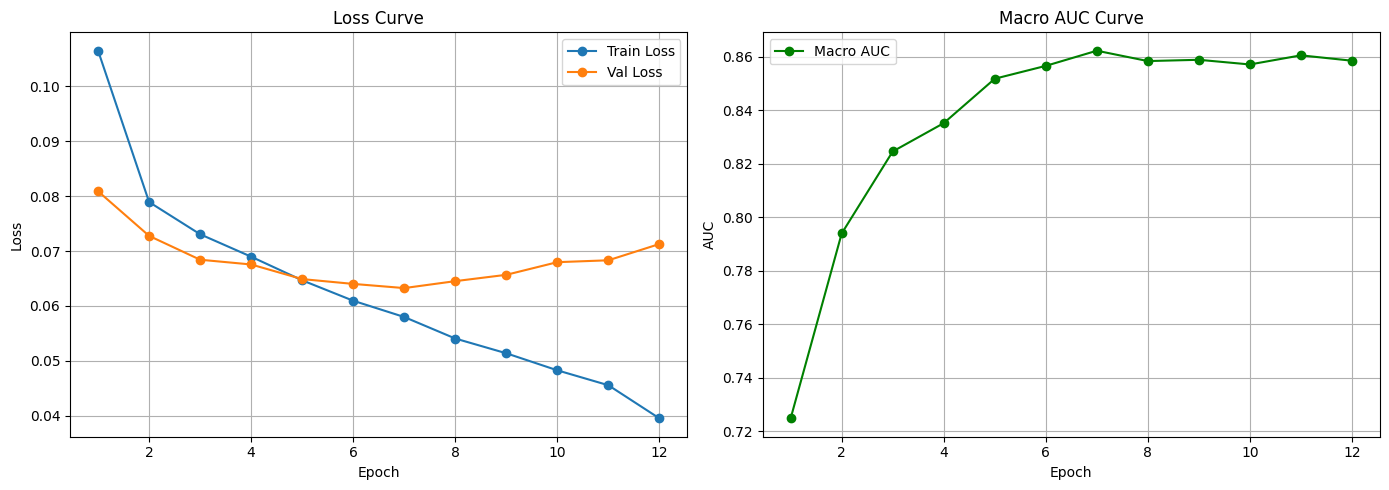

In [39]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(x, history['val_loss'], label='Val Loss', marker='o')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(x, history['macro_auc'], label='Macro AUC', marker='o', color='green')
ax2.set_title('Macro AUC Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 11. Grad-CAM Visualization

In [ ]:
# Loading the best model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

# Grad-CAM implementation
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        # Hook into last conv block of EfficientNet
        target_layer = model.backbone.blocks[-1]
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


gradcam = GradCAM(model)
print('Grad-CAM ready')

Grad-CAM ready


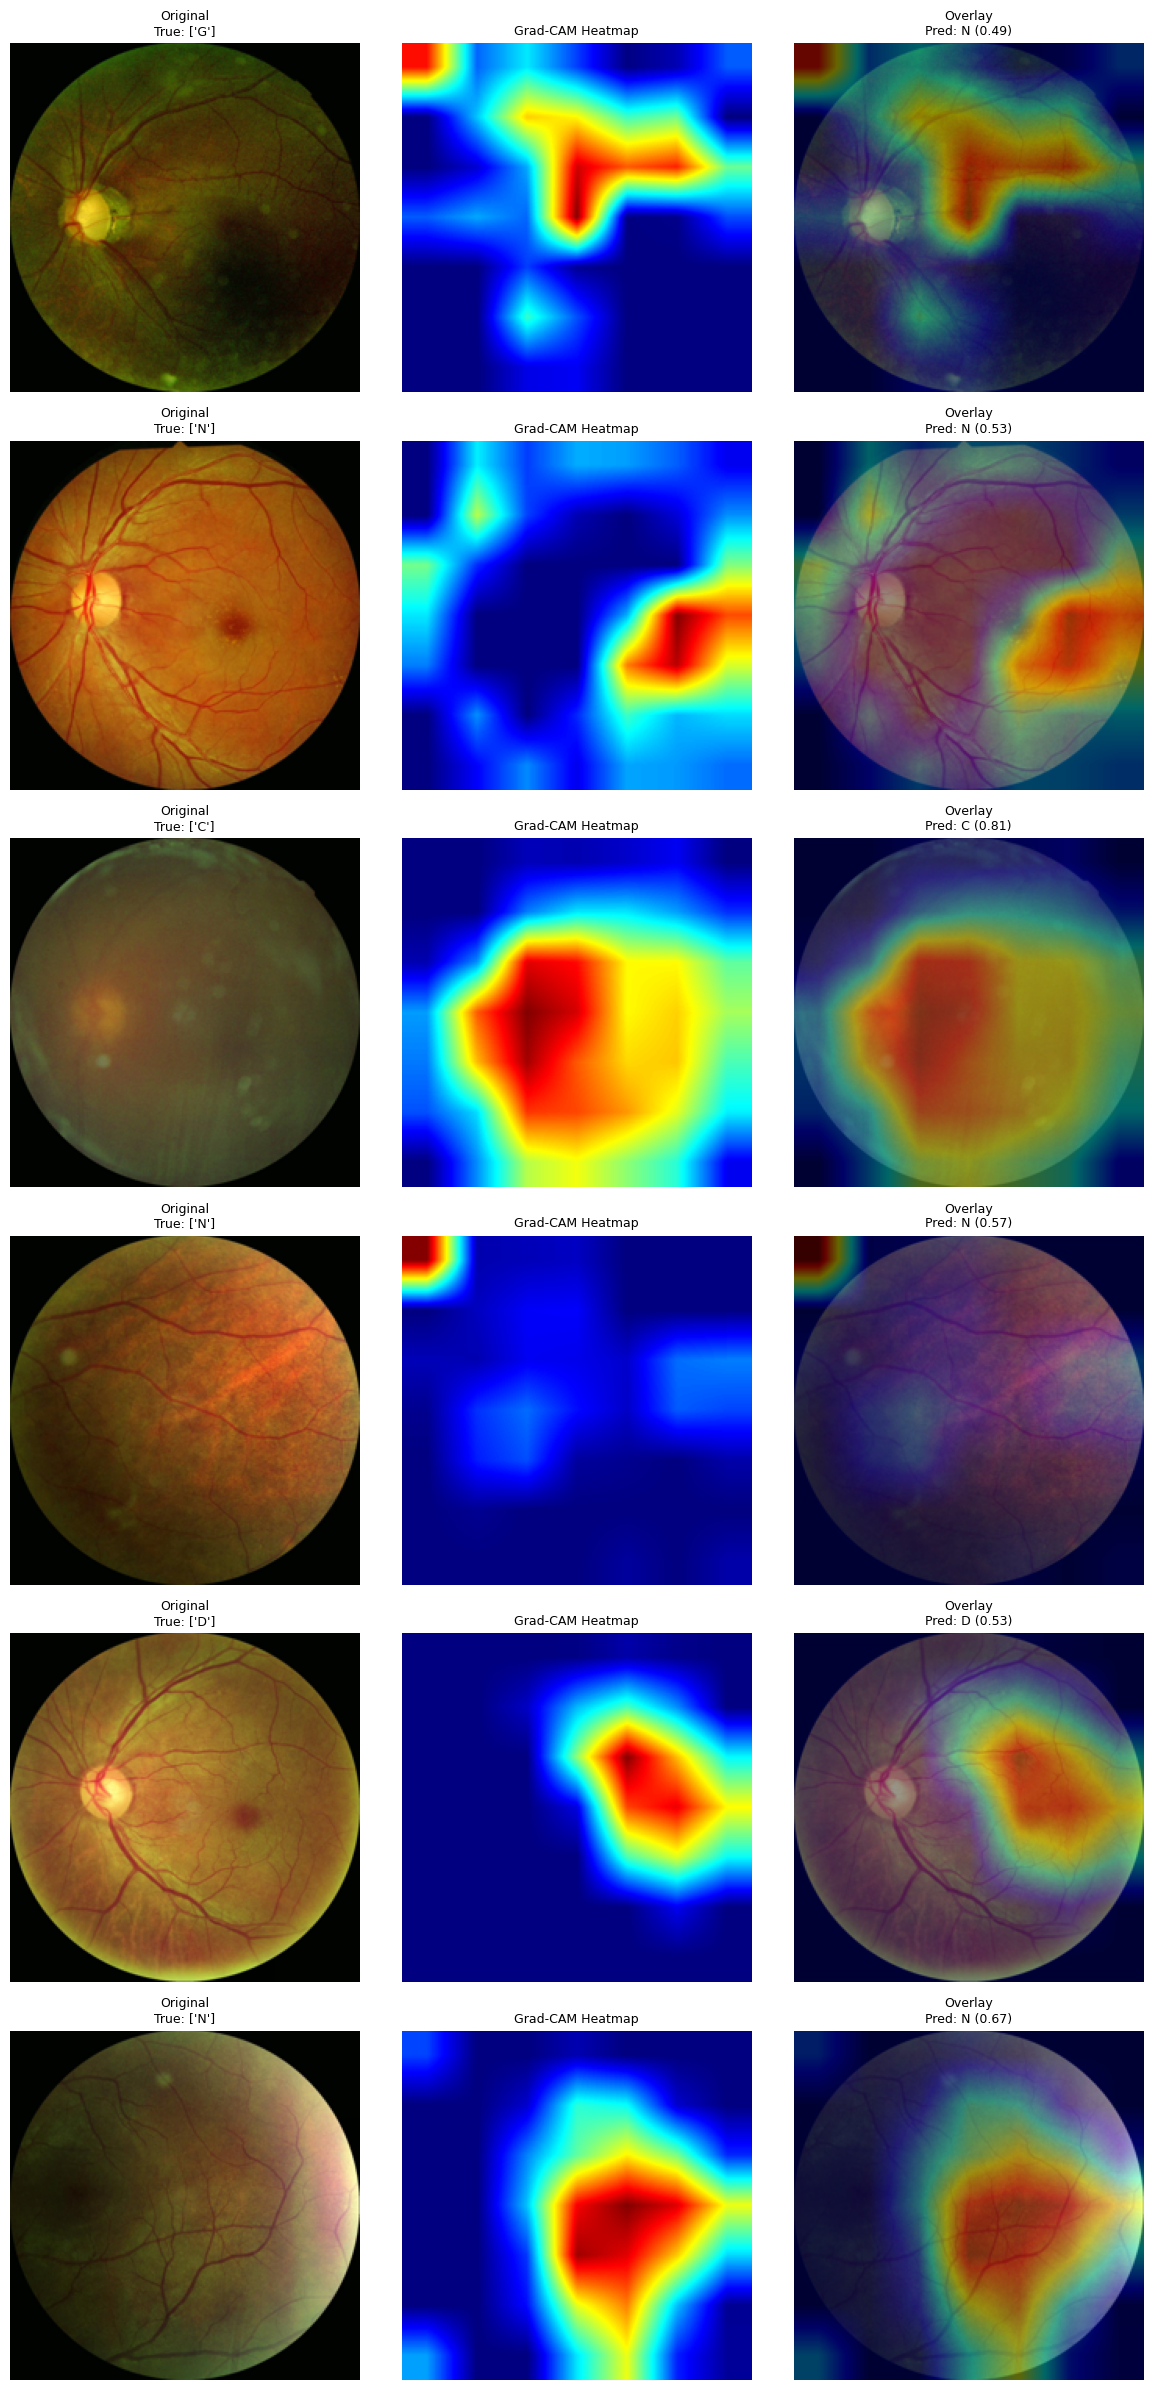

In [41]:
# Visualize Grad-CAM for sample images
sample = df_clean.sample(6, random_state=99)
fig, axes = plt.subplots(6, 3, figsize=(12, 24))

for i, (_, row) in enumerate(sample.iterrows()):
    fname = row['Left-Fundus'] if row['Left-Fundus'] is not None else row['Right-Fundus']
    img_path = PREPROCESSED_DIR + fname

    # Original image
    original = np.array(Image.open(img_path).convert('RGB'))
    original_resized = np.array(Image.fromarray(original).resize((IMG_SIZE, IMG_SIZE)))

    # Prepare tensor
    tensor = val_transform(Image.fromarray(original)).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    # Get prediction
    with torch.no_grad():
        preds = torch.sigmoid(model(tensor.detach())).cpu().numpy()[0]
    pred_class = np.argmax(preds)
    true_labels = [LABEL_COLS[j] for j in range(7) if row[LABEL_COLS[j]] == 1]

    # Generate Grad-CAM for top predicted class
    cam = gradcam.generate(tensor, pred_class)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.6 * original_resized + 0.4 * heatmap).astype(np.uint8)

    axes[i][0].imshow(original_resized)
    axes[i][0].set_title(f'Original\nTrue: {true_labels}', fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(heatmap)
    axes[i][1].set_title('Grad-CAM Heatmap', fontsize=9)
    axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Overlay\nPred: {LABEL_COLS[pred_class]} ({preds[pred_class]:.2f})', fontsize=9)
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_results.png', dpi=150)
plt.show()